In [1]:
#Initialization

import matplotlib.pyplot as plt
import numpy as np
#from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display, Math

#Widgets list

#choose the date
date = widgets.DatePicker(
    description='Date:',
    disabled=False
)

#type in your name/s
name = widgets.Textarea(
    value='',
    placeholder='Type your Name/s',
    description='Name:',
    disabled=False   
)

#type in your answers (box)
#check if & how math equations can be typed in
ans_box = widgets.Textarea(
    value='',
    placeholder='Type your answer in the space provided',
    description='Answer:',
    disabled=False
)


In [2]:
info = widgets.HBox([date, name])
info.layout.position = 'fixed'
info.layout.left = '500px'
display(info)

## Lab - Fibonacci Rabbits <sup>[[1]](#fn1)</sup><sup>[[2]](#fn2)</sup><sup>[[3]](#fn3)</sup>
### Structured Populations

**Instructions:**
- Writing math equations:
- Using the simulation:
- After you have completed your lab by filling in the answers in the spaces provided, use your web-browser's print function: **Ctrl+P/Cmd+P, then "Save as PDF" to print your Lab. You may submit this PDF file to Blackboard**.
- _Don't forget to include the appropriate units in your answers wherever relevant._

_**In this lab, we will learn about sustainable resource management through a fisheries model by modifying the logistic growth equation to incorporate different fishing rates.**_

**Topics covered:** Structured population, stability analysis through eigenvalues & eigenvectors.

**Learning Outcomes:** 
- Students will be able to appropriately modify a known differential equation based on how different harvesting rates affect the population.
- Students will be able to analyze the effect of the different harvest rates on the given population using phase-line diagrams and identifying equilibrium & inflection points.
- Students will be able to identify and calculate the optimal (maximal) choice of harvest rate that would still ensure the continual growth of the population, for the given differential equation model.

**Approx. time:** ~ 50-75 mins (estimate approx. time for different sections.)

**Introduction:** 

Given below is a brief introduction to what the **maximum sustainable yield** is and why it is an important quantity to study from a resource management perspective: __[Maximum Sustainable Yield](https://www.youtube.com/watch?v=hw5wso1lcfs)__.

<a id="fn1"></a>**[1]**
<a id="fn2"></a>**[2]**
<a id="fn3"></a>**[3]**

### Simulation
#### Description/How to use:


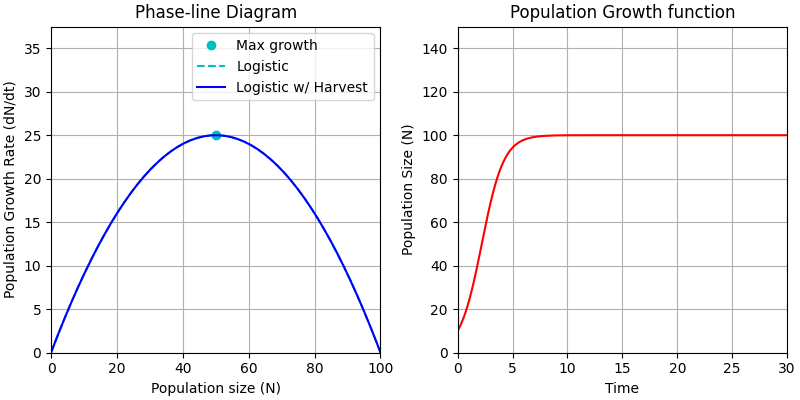

In [26]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
#from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display, Math


dt = 1e-4
t = np.arange(0,50,dt)
N = np.linspace(0,200,100)

#logistic growth function
def Log(N,r,K):
    """
    Return the logisitc growth function for population size N with intrinsic growth rate r and carrying capacity K.
    """
    return r*N*(1-(N/K))

#Harvesting rate function
def H(N,h): #H(t,N,w):
    """
    Return the harvest function, based on how it's related to the population size.
    """
    return h*N
        
#differential equation combining Logistic & different Harvest functions
def dNdt(N,r,K,h):
    """
    Return the differential equation combining Logistic & different Harvest functions.
    """
    return Log(N,r,K)-H(N,h)
    

#function to calculate the population in time
def N_sol(t,N0,r,K,h):
    N_t = [N0]
    for i in range(len(t)-1):
        N_t.append(N_t[i]+dt*dNdt(N_t[i],r,K,h)) #Forward-Euler
    
    return N_t

#setup plot
output = widgets.Output()
with output:
    fig, (ax1, ax2) = plt.subplots(1,2,constrained_layout=True, figsize=(8,4))
fig.canvas.toolbar_position = 'bottom'
#fig.suptitle('Logistic Growth with Harvesting')

Max_node, = ax1.plot([50],[25], 'co', label='Max growth')
# zero1, = ax1.plot([0],[0], 'bo', label='zero')
# zero2, = ax1.plot([100],[0], 'bo', label='zero')
line0, = ax1.plot(N, dNdt(N, 1, 100, 0), 'c--', label='Logistic')
line1, = ax1.plot(N, dNdt(N, 1, 100, 0), 'b-', label='Logistic w/ Harvest')
ax1.grid(True)
ax1.set_ylim(0,50)
ax1.set_xlim(0,100)
ax1.set_xlabel('Population size (N)')
ax1.set_ylabel('Population Growth Rate (dN/dt)')
ax1.set_title('Phase-line Diagram')
ax1.legend(loc='upper right')

line2, = ax2.plot(t, N_sol(t,10, 0.5, 100, 0), 'r-')
ax2.set_ylim(0,50)
ax2.set_xlim(0,30)
ax2.grid(True)
ax2.set_xlabel('Time')
ax2.set_ylabel('Population Size (N)')
ax2.set_title('Population Growth function')

# create widget control elements
r_val = widgets.FloatSlider(value=1, min = 0.00, max = 1.00, step = 0.01, description = r'$r$')
K_val = widgets.IntSlider(value=100, min = 1, max = 100, step = 1, description = r'$K$')
h_val = widgets.FloatSlider(value=0, min = 0, max = 1, step = 0.01, description = r'$h$')
N_0 = widgets.IntSlider(value = 10, min = 0, max = 200, step = 1, description = r'$N_0$')

def update(r,K,h,N0):    
    line0.set_ydata(dNdt(N,r,K,0))
    line1.set_ydata(dNdt(N,r,K,h))
    line2.set_ydata(N_sol(t,N0,r,K,h))
    Max_node.set_data([K/2],[r*K/4])
    ax1.set_ylim(0, 1.5*r*K/4)
    ax2.set_ylim(0,1.5*max(N_sol(t,N0,r,K,h)))
    fig.canvas.draw_idle()

# interactive_output matches dict keys to update()'s argument names
par_vals = widgets.interactive_output(update, {
    'r': r_val, 'K': K_val, 'h': h_val, 'N0': N_0
})

disp_eqn = widgets.HTMLMath(
    value = r"$\dfrac{dN}{dt}={r}N\left(1-\dfrac{N}{K}\right)-hN$",
    description= "Differential equation:"
)

harvest_func = widgets.RadioButtons(
    value = 'Constant Harvesting',
    options = ['Constant Harvesting', 'Variable Harvesting', 'Restocking'],
    description = 'Choose the harvest function:'
)

#study the logistic & harvesting functions as separate on the phase-line diagram or together as one single plot
graph_disp_opts = widgets.Checkbox(
    value=False, 
    description= 'Separate Logistic & Harvest graphs',
    disabled=False,
    indent=False
)

slopefield_disp_opt = widgets.Checkbox(
    value=False, 
    description= 'Show Slope-field',
    disabled=False,
    indent=False
)

#choose between which case-study/data you want to select
choose_data = widgets.RadioButtons(
    value = 'Lake in Bade, Nigeria',
    options = ['Lake in Bade, Nigeria', 'Atlantic Cod'],
    description = 'Choose case-study:'
)
# choose_data.layout.margin = '0px 10px 10px 0px'
# choose_data.layout.padding='5px 5px 5px 5px'
# choose_data.layout.width = '250px'
# choose_data.layout.border = 'solid 2.5px green'

par_vals = widgets.VBox([widgets.Label('Parameter values:'), r_val, K_val, h_val, N_0])
par_vals.layout.margin = '0px 10px 10px 0px'
par_vals.layout.padding='5px 5px 5px 5px'
par_vals.layout.width = '360px'
par_vals.layout.border = 'solid 2px green'

box2 = widgets.VBox([graph_disp_opts, harvest_func, disp_eqn])
box2.layout.margin = '0px 10px 10px 0px'
box2.layout.padding='5px 5px 5px 5px'
box2.layout.width = '360px'
box2.layout.border = 'solid 2.5px green'

box3 = widgets.VBox([choose_data, graph_disp_opts, slopefield_disp_opt])
box3.layout.margin = '0px 10px 10px 0px'
box3.layout.padding='5px 5px 5px 5px'
box3.layout.width = '300px'
box3.layout.border = 'solid 2.5px green'


widgets.HBox([par_vals, box2, box3])

_Recall the logistic growth model and analyze the growth rate at different population sizes through a phase-line diagram. Identify the maximum growth rate and the population at this point. Interpret these quantities on a population vs time graph._

Suppose the population size $N$ at time $t$ is modeled by the logistic equation:

$$ \dfrac{dN}{dt}=rN\left(1-\dfrac{N}{K}\right) $$ 

where the parameters are:
- $r$ - the intrinsic rate at which the population is growing
- $K$ - carrying capacity


Consider the follwing scenario:

A population of ___Atlantic cod___ are increasing with intrinsic growth $r=0.20$ and have a
carrying capacity of 2 million metric tons. Suppose each year, a commercial fishing quota removes a constant $h=0.01$ mmt of cod from the ocean. ([Cod fishery collapse of 1992](https://www.britannica.com/event/cod-fishery-collapse-of-1992))

#### Answer the following questions below using the simulation provided:

1. According to this model, for what values of $N$ does the population remain constant? _(Find the equilibrium points and state whether they are stable or unstable. State how the graph of $N(t)$ would look like for different initial values $N_0$.)_

In [4]:
display(ans_box)

Textarea(value='', description='Answer:', placeholder='Type your answer in the space provided')

2. For what value of $N$ does the population have the maximum growth rate? 

In [5]:
display(ans_box)

Textarea(value='', description='Answer:', placeholder='Type your answer in the space provided')

3. What is the maximum growth rate at this value? This value is known as the ___maximum sustainable yield (MSY)___.

In [6]:
display(ans_box)

Textarea(value='', description='Answer:', placeholder='Type your answer in the space provided')

__Constant Harvesting__

Suppose that the population is __harvested at a constant rate $h>0$__, how would the logistic equation change to accommodate this new harvesting rate? Write down the modified differential equation below:

display(ans_box)

5. Rewrite the equation above with the appropriate parameter values based on the given situation.
6. Use the phase-line diagram (dNdt vs N) for this modified logistic model to answer the following questions.

In [7]:
display(ans_box)

Textarea(value='', description='Answer:', placeholder='Type your answer in the space provided')

7. According to this model, for which values of N does the population remain constant? (Find the equilibrium points and state whether they are stable or unstable. State how the graph of N(t) would look like for different initial values N0 in relation to the new equilibrium points and their stability.)

In [8]:
display(ans_box)

Textarea(value='', description='Answer:', placeholder='Type your answer in the space provided')

8. For what value of N does the population have the maximum growth rate?

In [9]:
display(ans_box)

Textarea(value='', description='Answer:', placeholder='Type your answer in the space provided')

9. What is the maximum growth rate at this value?

In [10]:
display(ans_box)

Textarea(value='', description='Answer:', placeholder='Type your answer in the space provided')

10. Calculate the maximum sustainable yield for this model.

In [11]:
display(ans_box)

Textarea(value='', description='Answer:', placeholder='Type your answer in the space provided')

11. Study the model for different (constant) harvest rates compared to the maximum sustainable yield. How does the population behave when h<MSY? What about when h > MSY and when h=MSY? (Note your observations by using different values of h on the simulation provided.)

In [12]:
display(ans_box)

Textarea(value='', description='Answer:', placeholder='Type your answer in the space provided')

12. Based on your observations in the previous part, what harvest rates would assure the survival of the population in the long-term and for what harvest rates would the population eventually decline? What is the maximum possible harvest rate that would still assure that that population continues to grow in the long-term? 

In [13]:
display(ans_box)

Textarea(value='', description='Answer:', placeholder='Type your answer in the space provided')

__Variable Harvesting__

A population of Atlantic cod are increasing with intrinsic growth $r=0.20$ and have a carrying capacity of 2 million metric tons. Assume each year, a commercial fishing quota removes a constant $h=0.01$ mmt of cod from the ocean.


1. Write down the differential equation with the appropriate harvest function.
2. Draw the phase-line diagram (dNdt vs N) for this logistic model.
3. According to this model, for which values of N does the population remain constant? (Find the equilibrium points and state whether they are stable or unstable. State how the graph of N(t) would look like for different initial values N0.)
4. For what value of N does the population have the maximum growth rate? What is the maximal growth rate?
5. Based on your observations in the previous part, how is this different from the case with constant harvesting?
6. What would happen if we increased the harvest function so that it intersected the peak of the dNdt curve? How would it affect the size of harvest? How would it affect the stability properties of the system?
7. Study the model for different (constant) harvest rates compared to r. How does the population behave when h<r? What about when h > r and when h=r? (Note your observations by using different values of h on the simulation provided.)
8. If the population crashes how long does it take to crash? (need solution to diff eqn. N(t)). 1)     Summarize your analysis in (5)-(8) and include any thoughts or concerns you have about the modeling and make policy suggestions. Also answer the question, is a model with a fast crash of 10 years a better or worse situation that a model that has a crash in 30-40 years.
9. How Challenging is it to Sustainably Harvest Fish? Note that in most scenarios below the population will crash and that the important part of the question is how long this takes, which is a key part of your technical report. The longer it takes to crash the fishery the more time scientists have to notice the decline and take corrective action.  

In [14]:
display(ans_box)

Textarea(value='', description='Answer:', placeholder='Type your answer in the space provided')

___(Bonus)_ Restocking (Sigmoid Harvesting)__: The following equation models a logistic population that is periodically harvested and restocked with maximal rate $h > 0$. The period is $T = 2π/ω$.

$$\dfrac{dN}{dt}=rN\left(1-\dfrac{N}{K}\right)-hsin(wt)$$ 
